# Weeks 3+ — Working with the full release (~79M rows) without downloading 79M rows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ariba86/flyrank-ml-internship/blob/main/notebooks/03_working_with_the_full_release.ipynb?flush_cache=true)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


In [1]:
%pip -q install duckdb huggingface_hub


In [2]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [3]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [4]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Build features with SQL, not with RAM

The pattern for every lane: **aggregate per content item inside DuckDB**, then hand the small
result to pandas/sklearn. Here: momentum features from the last 60 days of the panel.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It downloads ~2 months of column data over the network (RAM stays tiny; that's the point). If it runs past ~10 minutes or errors with `HTTP 429`, re-run this section against `TABLES['fact_daily_sample']` and save the full table for your final pass.


In [5]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,1110.0,955.0,12.0,7.543789
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3735.0,3338.0,33.0,5.446636
2,client_e547b89c05043229,content_401dcc5cd616e3dd,181.0,130.0,0.0,6.874167
3,client_e547b89c05043229,content_18d95bd7890430ed,151.0,340.0,0.0,33.665367
4,client_e547b89c05043229,content_56f46c55f0348ab4,392.0,531.0,3.0,12.995100


## 4. Add query-level signals

`fact_content_query_90d` describes **how a page earns its impressions**: across how many
distinct queries, how concentrated, how much sits in the rare/anonymized tail. One page ranking
for 40 queries is a different animal from one page ranking for 2.


In [6]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
print(f'joined: {len(data):,} rows')
data.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,1110.0,955.0,12.0,7.543789,1.0,0.022750,0.957216,59.0,59.0,1.000000
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3735.0,3338.0,33.0,5.446636,14.0,0.017946,0.932994,84.0,462.0,0.181818
2,client_e547b89c05043229,content_401dcc5cd616e3dd,181.0,130.0,0.0,6.874167,3.0,0.162037,0.552469,153.0,185.0,0.827027
3,client_e547b89c05043229,content_18d95bd7890430ed,151.0,340.0,0.0,33.665367,2.0,0.108932,0.820261,52.0,65.0,0.800000
4,client_e547b89c05043229,content_56f46c55f0348ab4,392.0,531.0,3.0,12.995100,5.0,0.163052,0.788332,14.0,65.0,0.215385


## 5. A first honest model

Same shape as notebook 02: define a label, hold out data, compare against a dumb baseline.
Label: *did impressions decline by more than 20% month-over-month?* — built only from columns
that exist **before** the window we predict. (Momentum features from the last 30 days predicting
a label defined on those same 30 days would be leakage — so here the features come from the
prev-30 window and query-mix, and the label from the last-30 outcome.)


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

feature_cols = ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=feature_cols)
X, y = model_data[feature_cols], model_data['is_declining']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

print(f'base rate (always predict majority): {max(y_te.mean(), 1 - y_te.mean()):.3f}')
print(classification_report(y_te, model.predict(X_te), digits=3))


Whatever number you just got: interrogate it before you believe it. Which feature carries the
signal? Does it survive a per-client split (train on some clients, test on others)? That
question — *does it generalize across clients?* — is exactly what separates a capstone-grade
result from a lucky split.

## Your turn

1. Re-run section 3 with a **90-day** window and a `HAVING` threshold of your choice.
2. Add one feature you believe in (position volatility? weekend share? query concentration?).
3. Replace the random split with **GroupShuffleSplit on `client_hash_id`** and compare.

## Working locally instead

```python
from huggingface_hub import snapshot_download
path = snapshot_download(repo_id='FlyRank/internship-warehouse', repo_type='dataset',
                         allow_patterns=['dim_*.parquet', 'fact_content_query_90d.parquet',
                                         'fact_content_daily_performance/month=2026-0*/*.parquet'])
```
Then point `REL` at that local path. Download only the month partitions you need — the
`allow_patterns` filter above is the whole trick.

---

**Where this fits:** every lane brief assumes you can produce per-content feature tables like
the one you just built. The lane datasets under the `lanes` HF repo are pre-cut examples of
exactly this pattern — but for the capstone, features you engineered yourself from the full
release beat any pre-cut file.


In [7]:
# Ye columns clustering ke liye use honge
feature_cols = ['imp_last30', 'imp_prev30', 'clk_last30', 'pos_last30',
                 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']

# Missing values wali rows hata do
cluster_data = data.dropna(subset=feature_cols).copy()
print(f'{len(cluster_data):,} rows clustering ke liye ready hain')

101,620 rows clustering ke liye ready hain


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data[feature_cols])

print('Scaling done. Shape:', X_scaled.shape)

Scaling done. Shape: (101620, 8)


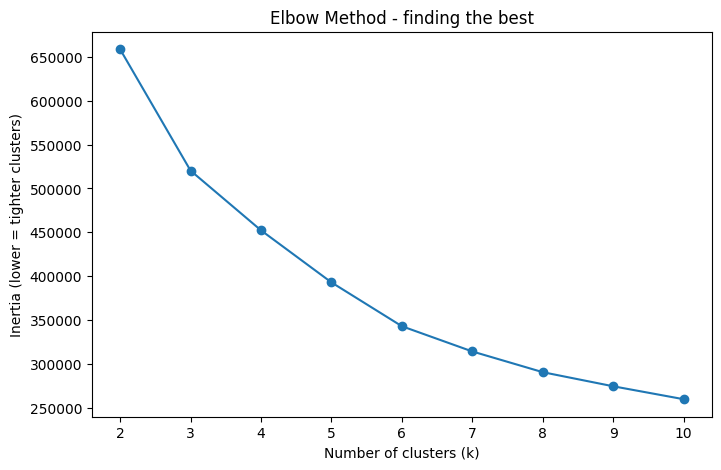

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method - finding the best')
plt.show()

In [12]:
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_data['cluster'] = kmeans.fit_predict(X_scaled)

print(cluster_data['cluster'].value_counts().sort_index())

cluster
0     3482
1    18162
2    22771
3    57053
4      152
Name: count, dtype: int64


In [13]:
cluster_profile = cluster_data.groupby('cluster')[feature_cols].mean().round(2)
cluster_profile['count'] = cluster_data['cluster'].value_counts().sort_index()
cluster_profile

,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_share,count
cluster,,,,,,,,,
0,20357.85,23760.65,67.32,9.37,160.58,0.03,0.62,0.18,3482
1,287.61,452.14,0.38,48.77,11.27,0.30,0.35,0.38,18162
2,460.70,654.70,2.21,15.98,3.76,0.10,0.76,0.76,22771
3,1749.59,2256.46,7.06,14.71,24.24,0.08,0.73,0.26,57053
4,107822.47,105494.73,437.45,7.40,595.89,0.04,0.51,0.19,152


In [14]:
cluster_names = {
    0: 'High-Traffic Decliner',
    1: 'Buried / Weak',
    2: 'One-Query Dependent',
    3: 'Steady Middle',
    4: 'Elite Grower'
}

cluster_actions = {
    0: 'improve',      # bara traffic hai lekin gir raha hai - turant review chahiye
    1: 'prune',        # kam traffic, kharab rank - shayad chorne ya merge karne layak
    2: 'improve',       # ek query par depend, risky - content diversify karo
    3: 'monitor',       # average, khaas action ki zaroorat nahi filhaal
    4: 'protect'        # sabse achay performers - inko chero mat, protect karo
}

cluster_data['archetype'] = cluster_data['cluster'].map(cluster_names)
cluster_data['recommended_action'] = cluster_data['cluster'].map(cluster_actions)

# Final summary table
summary = cluster_data.groupby(['cluster', 'archetype', 'recommended_action']).size().reset_index(name='count')
summary

,cluster,archetype,recommended_action,count
0,0,High-Traffic Decliner,improve,3482
1,1,Buried / Weak,prune,18162
2,2,One-Query Dependent,improve,22771
3,3,Steady Middle,monitor,57053
4,4,Elite Grower,protect,152


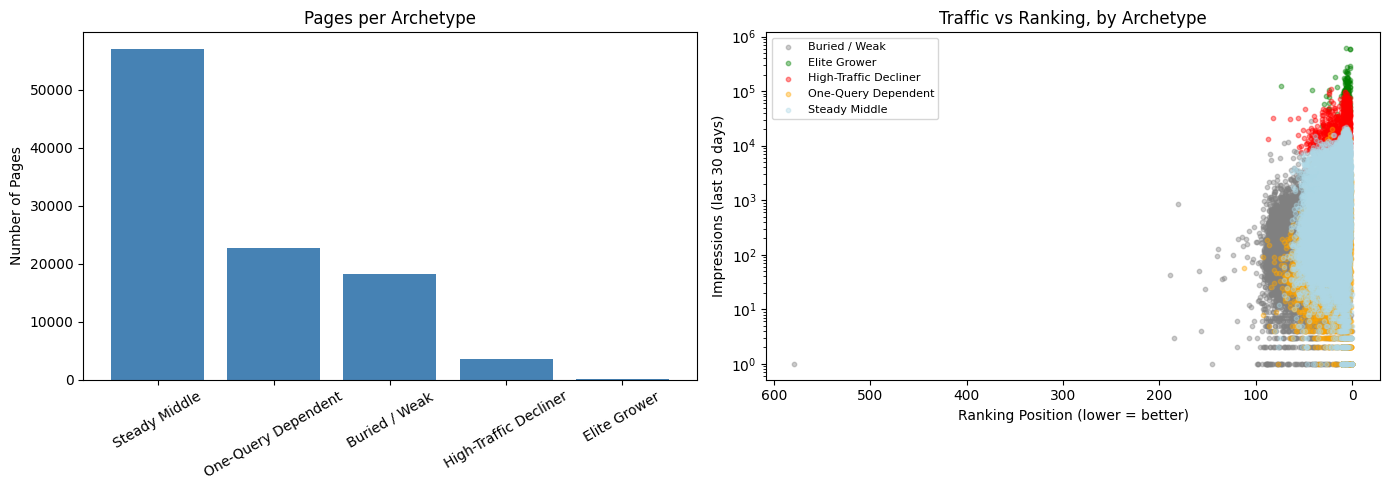

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Har archetype mein kitne pages hain
archetype_counts = cluster_data['archetype'].value_counts()
axes[0].bar(archetype_counts.index, archetype_counts.values, color='steelblue')
axes[0].set_title('Pages per Archetype')
axes[0].set_ylabel('Number of Pages')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Traffic vs Ranking position, color se archetype dikhana
colors = {'High-Traffic Decliner': 'red', 'Buried / Weak': 'gray',
          'One-Query Dependent': 'orange', 'Steady Middle': 'lightblue',
          'Elite Grower': 'green'}

for name, group in cluster_data.groupby('archetype'):
    axes[1].scatter(group['pos_last30'], group['imp_last30'],
                     label=name, alpha=0.4, s=10, color=colors[name])

axes[1].set_xlabel('Ranking Position (lower = better)')
axes[1].set_ylabel('Impressions (last 30 days)')
axes[1].set_yscale('log')  # bara range ki wajah se log scale
axes[1].set_title('Traffic vs Ranking, by Archetype')
axes[1].legend(fontsize=8)
axes[1].invert_xaxis()  # taake best ranking (chota number) left mein dikhe

plt.tight_layout()
plt.savefig('cluster_analysis.png', dpi=150)
plt.show()

In [16]:
# Simple baseline: sirf traffic (imp_last30) ke basis par 3 buckets
def simple_baseline(imp):
    if imp >= 10000:
        return 'High Traffic'
    elif imp >= 500:
        return 'Medium Traffic'
    else:
        return 'Low Traffic'

cluster_data['baseline_group'] = cluster_data['imp_last30'].apply(simple_baseline)

# Compare: baseline groups vs actual K-means clusters
comparison = cluster_data.groupby(['baseline_group', 'archetype']).size().unstack(fill_value=0)
print(comparison)

archetype       Buried / Weak  Elite Grower  High-Traffic Decliner  \
baseline_group                                                       
High Traffic                6           151                   2810   
Low Traffic             15731             0                      2   
Medium Traffic           2425             1                    670   

archetype       One-Query Dependent  Steady Middle  
baseline_group                                      
High Traffic                     33            940  
Low Traffic                   17459          19917  
Medium Traffic                 5279          36196  


In [17]:
import numpy as np
from sklearn.metrics import silhouette_score

# Note: pura dataset bara hai, isliye ek sample lete hain (fast chalne ke liye)
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=10000, replace=False)
score = silhouette_score(X_scaled[sample_idx], cluster_data['cluster'].values[sample_idx])

print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.295


In [18]:
# Check: kya har client mein saari archetypes dikhti hain, ya sirf kuch clients ek archetype dominate karte hain?
client_archetype_check = cluster_data.groupby('client_hash_id')['archetype'].nunique()
print('Clients with only 1 archetype:', (client_archetype_check == 1).sum())
print('Clients with 3+ archetypes:', (client_archetype_check >= 3).sum())
print('Total clients:', cluster_data['client_hash_id'].nunique())

Clients with only 1 archetype: 1
Clients with 3+ archetypes: 40
Total clients: 47
